In [1]:
from kafka import KafkaConsumer
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.ion()
import time
from collections import defaultdict
from IPython.display import clear_output

In [2]:
# ── Kafka configuration ────────────────────────────────────────────────────────
OUTPUT_TOPIC            = "aeration_predictions"   # topic written by the ML producer
KAFKA_BOOTSTRAP_SERVERS = ["localhost:9092"]
GROUP_ID                = "dashboard_group"

MAX_POINTS = 100   # rolling window per sensor
PLOT_EVERY = 5     # regenerate PNGs every N messages

In [3]:
sensor_store = defaultdict(lambda: {
    'all_timestamps':   [],
    'all_predictions':  [],
    'ts_aeration':      [],
    'conf_aeration':    [],
    'ts_no_aeration':   [],
    'conf_no_aeration': [],
})
msg_counter = 0

In [4]:
def plot_dashboard(sensor_id, sd):
    """
    Muestra un dashboard de 3 subplots en el notebook.
    3.3.1 - estado de aireación (0/1)
    3.3.2 - proba_aeration cuando pred == 1
    3.3.3 - proba_no_aeration cuando pred == 0
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    fig.suptitle(f'Inference Dashboard - Sensor {sensor_id}', fontsize=14, fontweight='bold')

    # 3.3.1 - Estado de aireación (Paso a paso)
    ax1 = axes[0]
    if sd['all_timestamps']:
        ax1.step(sd['all_timestamps'], sd['all_predictions'], where='post', color='royalblue', lw=2)
        # Puntos de color para identificar visualmente ON/OFF
        ts_on = [t for t, p in zip(sd['all_timestamps'], sd['all_predictions']) if p == 1]
        ts_off = [t for t, p in zip(sd['all_timestamps'], sd['all_predictions']) if p == 0]
        if ts_on: ax1.scatter(ts_on, [1]*len(ts_on), color='green', label='Aeration ON', zorder=5)
        if ts_off: ax1.scatter(ts_off, [0]*len(ts_off), color='red', label='Aeration OFF', zorder=5)
    
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['No (0)', 'Yes (1)'])
    ax1.set_title('3.3.1 - Aeration State')
    ax1.legend(loc='upper right')

    # 3.3.2 - Confianza Clase Aireación (Solo cuando pred == 1)
    ax2 = axes[1]
    if sd['ts_aeration']:
        ax2.bar(range(len(sd['ts_aeration'])), sd['conf_aeration'], color='mediumseagreen')
        ax2.set_xticks(range(len(sd['ts_aeration'])))
        ax2.set_xticklabels([str(t)[-5:] for t in sd['ts_aeration']], rotation=45)
    ax2.set_title('3.3.2 - Confidence when prediction = 1 (Aeration)')
    ax2.set_ylim(0, 1.1)

    # 3.3.3 - Confianza Clase No Aireación (Solo cuando pred == 0)
    ax3 = axes[2]
    if sd['ts_no_aeration']:
        ax3.bar(range(len(sd['ts_no_aeration'])), sd['conf_no_aeration'], color='tomato')
        ax3.set_xticks(range(len(sd['ts_no_aeration'])))
        ax3.set_xticklabels([str(t)[-5:] for t in sd['ts_no_aeration']], rotation=45)
    ax3.set_title('3.3.3 - Confidence when prediction = 0 (No Aeration)')
    ax3.set_ylim(0, 1.1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    display(fig)
    plt.close(fig)

In [5]:
# ── Initialize consumer ─────────────────────────────────────────────────────────
consumer = KafkaConsumer(
    OUTPUT_TOPIC,
    bootstrap_servers  = KAFKA_BOOTSTRAP_SERVERS,
    group_id           = GROUP_ID,
    auto_offset_reset  = 'latest',
    enable_auto_commit = True,
    value_deserializer = lambda m: json.loads(m.decode('utf-8')),
    key_deserializer   = lambda k: k.decode('utf-8') if k else None,
)

print(f"Subscribed to Kafka topic '{OUTPUT_TOPIC}'.")
print('Waiting for inference results... (Kernel -> Interrupt to stop)\n')

Subscribed to Kafka topic 'aeration_predictions'.
Waiting for inference results... (Kernel -> Interrupt to stop)



In [6]:
msg_counter = 0
try:
    for message in consumer:
        res = message.value
        sid = res['sensor_id']
        
        # Guardar datos (Lógica simplificada)
        sd = sensor_store[sid]
        sd['all_timestamps'].append(res['timestamp'])
        sd['all_predictions'].append(res['prediction'])
        if res['prediction'] == 1:
            sd['ts_aeration'].append(res['timestamp'])
            sd['conf_aeration'].append(res['proba_aeration'])
        else:
            sd['ts_no_aeration'].append(res['timestamp'])
            sd['conf_no_aeration'].append(res['proba_no_aeration'])

        # Limpiar histórico
        for k in sd: sd[k] = sd[k][-MAX_POINTS:]

        msg_counter += 1
        
        # **Actualización visual**
        if msg_counter % PLOT_EVERY == 0:
            clear_output(wait=True)
            print(f"Último mensaje: Sensor {sid} | Pred: {res['prediction']}")
            for s_id, storage in sensor_store.items():
                plot_dashboard(s_id, storage)

except KeyboardInterrupt:
    print("Detenido.")

Último mensaje: Sensor 3 | Pred: 1


<Figure size 1000x1000 with 3 Axes>

<Figure size 1000x1000 with 3 Axes>

<Figure size 1000x1000 with 3 Axes>

Detenido.


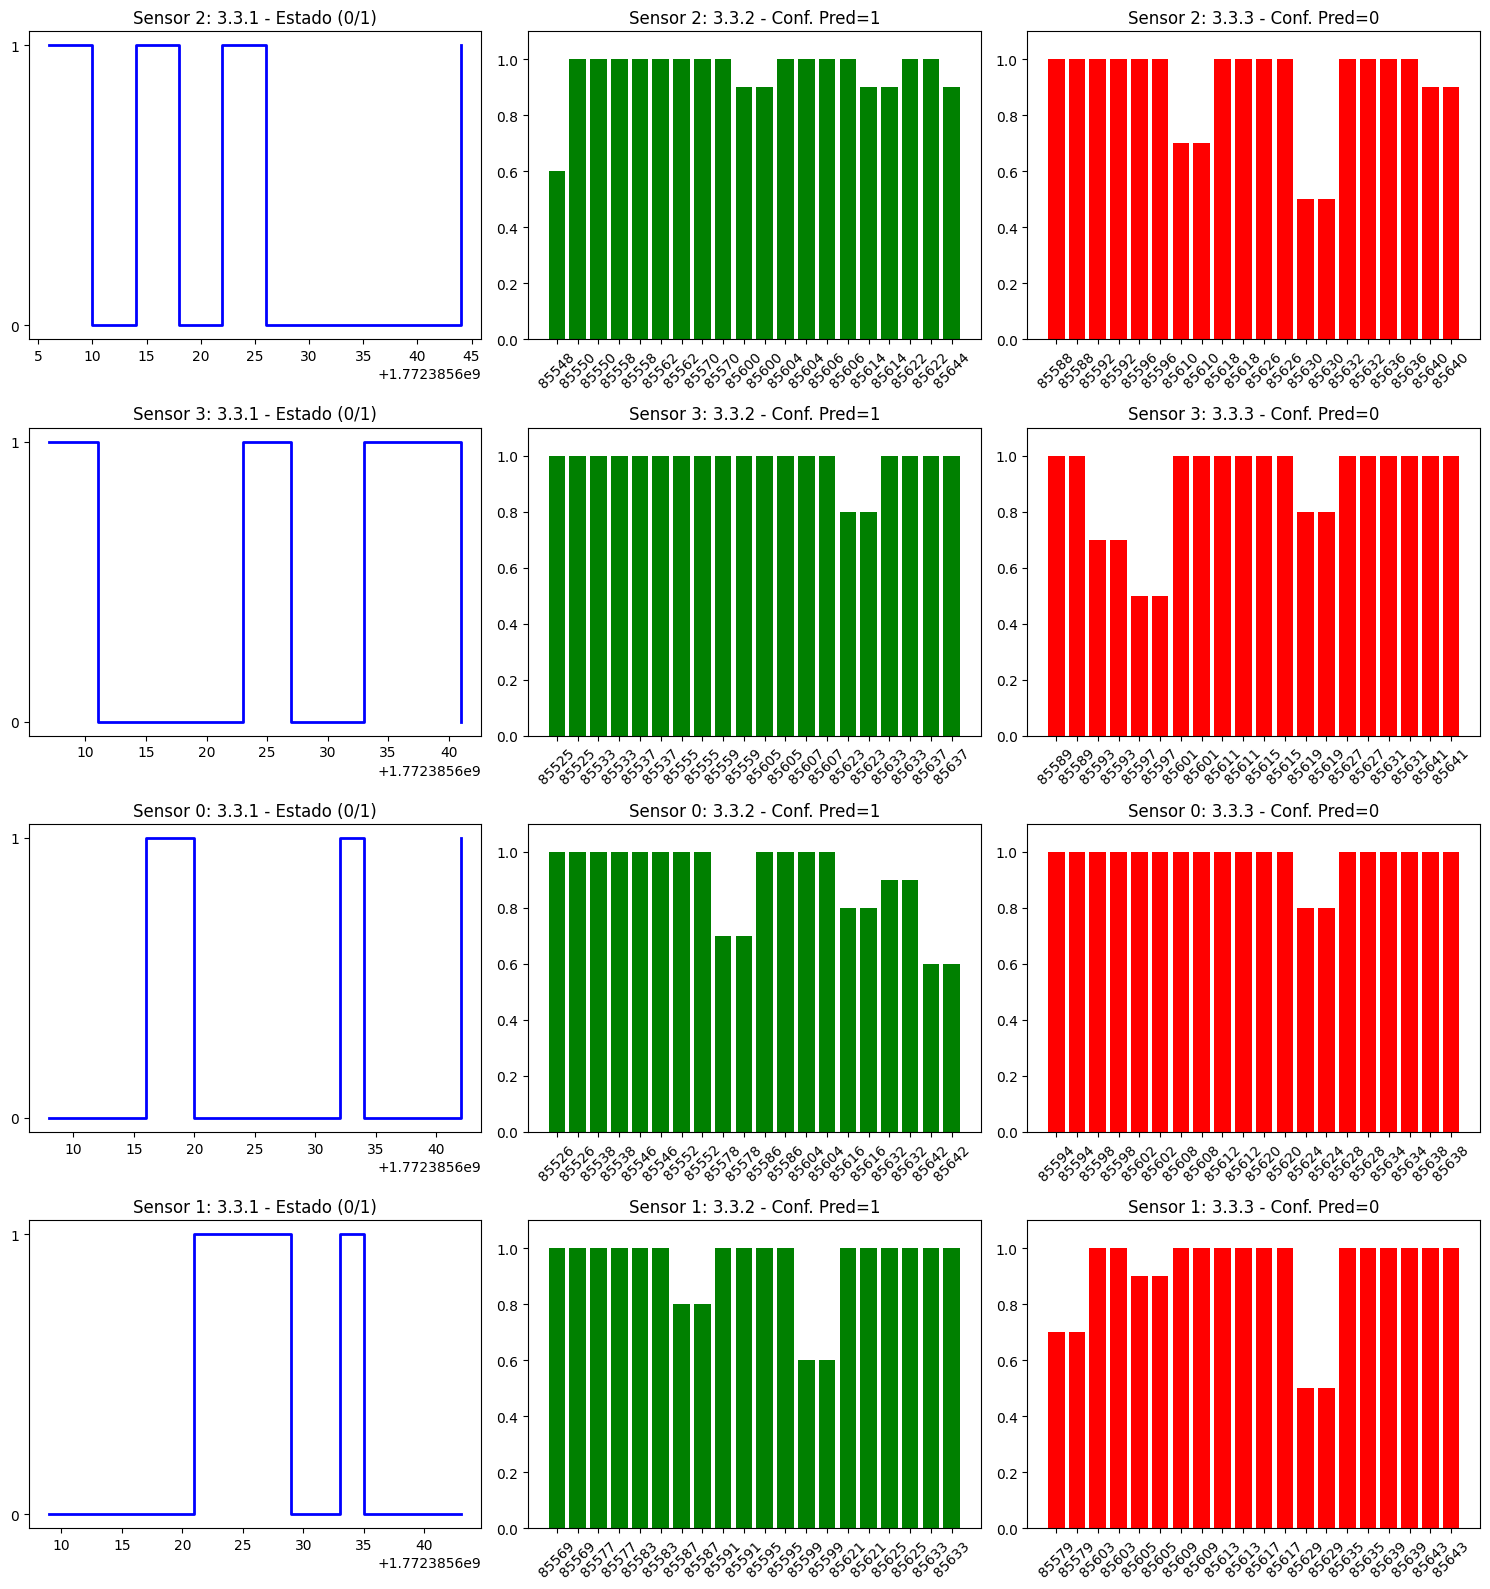

Sensor 2 | Pred: 1 | Prob(0): 0.1 | Prob(1): 0.9
Sensor 3 | Pred: 0 | Prob(0): 0.9 | Prob(1): 0.1
Sensor 3 | Pred: 0 | Prob(0): 0.9 | Prob(1): 0.1
Sensor 0 | Pred: 0 | Prob(0): 1.0 | Prob(1): 0.0
Sensor 0 | Pred: 0 | Prob(0): 1.0 | Prob(1): 0.0


In [ ]:
%matplotlib inline
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from kafka import KafkaConsumer
from collections import defaultdict

# Configuración
KAFKA_BOOTSTRAP_SERVERS = ["localhost:9092"]
OUTPUT_TOPIC = "aeration_predictions"
MAX_POINTS = 20
PLOT_EVERY = 5 

sensor_store = defaultdict(lambda: {
    'ts': [], 'pred': [],
    'ts_aer': [], 'conf_aer': [],
    'ts_no_aer': [], 'conf_no_aer': []
})

def plot_all_dashboards(store):
    """Genera, muestra y guarda **un único dashboard** con todos los sensores."""
    n_sensors = len(store)
    if n_sensors == 0: return

    # Crea una cuadrícula: n_sensors filas x 3 columnas
    fig, axes = plt.subplots(n_sensors, 3, figsize=(15, 4 * n_sensors))
    
    # Ajuste por si de momento solo ha llegado 1 sensor (para que no falle el indexado)
    if n_sensors == 1: axes = [axes]

    for idx, (sensor_id, sd) in enumerate(store.items()):
        # 3.3.1 Estado de aireación (Columna 0)
        if sd['ts']:
            axes[idx][0].step(sd['ts'], sd['pred'], where='post', color='blue', lw=2)
        axes[idx][0].set_title(f'Sensor {sensor_id}: 3.3.1 - Estado (0/1)')
        axes[idx][0].set_yticks([0, 1])

        # 3.3.2 Confianza (Pred == 1) (Columna 1)
        if sd['ts_aer']:
            axes[idx][1].bar(range(len(sd['ts_aer'])), sd['conf_aer'], color='green')
            axes[idx][1].set_xticks(range(len(sd['ts_aer'])))
            axes[idx][1].set_xticklabels([str(t)[-5:] for t in sd['ts_aer']], rotation=45)
        axes[idx][1].set_title(f'Sensor {sensor_id}: 3.3.2 - Conf. Pred=1')
        axes[idx][1].set_ylim(0, 1.1)

        # 3.3.3 Confianza (Pred == 0) (Columna 2)
        if sd['ts_no_aer']:
            axes[idx][2].bar(range(len(sd['ts_no_aer'])), sd['conf_no_aer'], color='red')
            axes[idx][2].set_xticks(range(len(sd['ts_no_aer'])))
            axes[idx][2].set_xticklabels([str(t)[-5:] for t in sd['ts_no_aer']], rotation=45)
        axes[idx][2].set_title(f'Sensor {sensor_id}: 3.3.3 - Conf. Pred=0')
        axes[idx][2].set_ylim(0, 1.1)

    plt.tight_layout()
    # **Guarda una sola imagen grande**
    plt.savefig('dashboard_todos_sensores.png')
    display(fig)
    plt.close(fig)

# Inicialización
consumer = KafkaConsumer(
    OUTPUT_TOPIC,
    bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
    value_deserializer=lambda m: json.loads(m.decode('utf-8'))
)

msg_counter = 0

try:
    for message in consumer:
        res = message.value
        sid = res['sensor_id']
        ts = res['timestamp']
        pred = res['prediction']
        
        # Guardar en memoria
        sd = sensor_store[sid]
        sd['ts'].append(ts)
        sd['pred'].append(pred)
        
        if pred == 1:
            sd['ts_aer'].append(ts)
            sd['conf_aer'].append(res['proba_aeration'])
        else:
            sd['ts_no_aer'].append(ts)
            sd['conf_no_aer'].append(res['proba_no_aeration'])

        # Mantener tamaño máximo
        for k in sd: sd[k] = sd[k][-MAX_POINTS:]

        msg_counter += 1
        
        # Imprime por pantalla
        print(f"Sensor {sid} | Pred: {pred} | Prob(0): {res['proba_no_aeration']} | Prob(1): {res['proba_aeration']}")

        # **Actualiza la super-gráfica pasándole el diccionario entero**
        if msg_counter % PLOT_EVERY == 0:
            clear_output(wait=True)
            plot_all_dashboards(sensor_store)

except KeyboardInterrupt:
    print("Ejecución finalizada.")